In [2]:
from google.colab import files
uploaded = files.upload()

Saving ab_testing_dataset.xlsx to ab_testing_dataset.xlsx


In [3]:
import pandas as pd

df = pd.read_excel("ab_testing_dataset.xlsx")
df.head()

,user_id,group,converted
0,1,A,0
1,2,B,1
2,3,A,0
3,4,A,0
4,5,A,0


In [4]:
df.groupby('group')['converted'].mean()


,converted
group,
A,0.098592
B,0.187166


In [6]:
from statsmodels.stats.proportion import proportions_ztest

# Get conversions and total users
conversions = df.groupby('group')['converted'].sum()
visitors = df.groupby('group')['converted'].count()

# Perform Z-test
z_stat, p_value = proportions_ztest(conversions, visitors)

print("Z-stat:", z_stat)
print("P-value:", p_value)

Z-stat: -2.5472685427028883
P-value: 0.010856984876949267


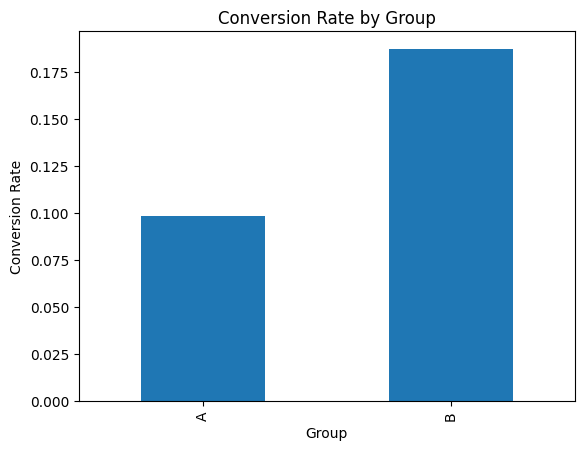

In [7]:
import matplotlib.pyplot as plt

df.groupby('group')['converted'].mean().plot(kind='bar')
plt.title("Conversion Rate by Group")
plt.xlabel("Group")
plt.ylabel("Conversion Rate")
plt.show()